In [1]:
# Imports
import pandas as pd
import numpy as np
import mlflow
import mlflow.sklearn
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
import os
import sys

# Add parent directory to path so we can import config
sys.path.append('..')

# Load config
with open('config.yaml') as f:
    cfg = yaml.safe_load(f)

# Set MLflow
mlflow.set_tracking_uri('../mlruns')
mlflow.set_experiment('apple-segment-classifier')

print("Setup complete!")
print(f"MLflow tracking URI: {mlflow.get_tracking_uri()}")

Setup complete!
MLflow tracking URI: ../mlruns


c:\Users\Administrador.5198WortenAmo\anaconda3\Lib\site-packages\mlflow\tracking\_tracking_service\utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)


In [2]:
# Load and prepare data
import category_encoders as ce
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer

df = pd.read_csv('../data/apple_sales.csv')

# Drop irrelevant columns
drop_cols = [c for c in cfg['features']['drop_columns'] if c in df.columns]
df = df.drop(columns=drop_cols)

feature_cols = (
    cfg['features']['categorical_high_cardinality']
    + cfg['features']['categorical_ohe']
    + cfg['features']['ordinal']
)
X = df[feature_cols]
y = df[cfg['features']['target']]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {len(X_train):,} | Test: {len(X_test):,}")
print(f"\nFeatures: {feature_cols}")
print(f"\nTarget distribution:\n{y.value_counts()}")

Train: 9,200 | Test: 2,300

Features: ['country', 'city', 'product_name', 'color', 'category', 'region', 'customer_age_group']

Target distribution:
customer_segment
Government    2892
Individual    2885
Education     2884
Business      2839
Name: count, dtype: int64


In [3]:
# Build preprocessor
high_card = cfg['features']['categorical_high_cardinality']
ohe_cols  = cfg['features']['categorical_ohe']
ord_cols  = cfg['features']['ordinal']
ord_cats  = [cfg['features']['ordinal_categories'][c] for c in ord_cols]

preprocessor = ColumnTransformer(transformers=[
    ("target_enc", ce.TargetEncoder(cols=high_card), high_card),
    ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False), ohe_cols),
    ("ordinal", OrdinalEncoder(
        categories=ord_cats,
        handle_unknown="use_encoded_value",
        unknown_value=-1
    ), ord_cols),
], remainder="drop")

X_train_t = preprocessor.fit_transform(X_train, y_train)
X_test_t  = preprocessor.transform(X_test)

print(f"Transformed shape: {X_train_t.shape}")

Transformed shape: (9200, 19)


In [4]:
# Scenario 1 — Baseline models
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

print("=== SCENARIO 1: BASELINE MODELS ===\n")

baselines = {
    "majority_class": DummyClassifier(strategy="most_frequent"),
    "logistic_regression": LogisticRegression(max_iter=1000, random_state=42)
}

results = {}

for name, model in baselines.items():
    with mlflow.start_run(run_name=f"scenario1_{name}"):
        model.fit(X_train_t, y_train)
        y_pred = model.predict(X_test_t)
        
        acc = accuracy_score(y_test, y_pred)
        f1  = f1_score(y_test, y_pred, average="weighted")
        
        mlflow.log_param("model", name)
        mlflow.log_param("scenario", 1)
        mlflow.log_metrics({"accuracy": acc, "f1_weighted": f1})
        
        results[name] = {"accuracy": acc, "f1": f1}
        print(f"{name}: Acc={acc:.4f} | F1={f1:.4f}")

print("\nScenario 1 complete! Check MLflow UI at http://localhost:5000")

=== SCENARIO 1: BASELINE MODELS ===

majority_class: Acc=0.2513 | F1=0.1009
logistic_regression: Acc=0.2543 | F1=0.2414

Scenario 1 complete! Check MLflow UI at http://localhost:5000


In [5]:
# Scenario 2 — Random Forest experiments
from sklearn.ensemble import RandomForestClassifier

print("=== SCENARIO 2: RANDOM FOREST EXPERIMENTS ===\n")

rf_configs = [
    {"n_estimators": 50,  "max_depth": 5,    "min_samples_split": 2},
    {"n_estimators": 100, "max_depth": 10,   "min_samples_split": 2},
    {"n_estimators": 200, "max_depth": None, "min_samples_split": 5},
]

for config in rf_configs:
    run_name = f"rf_n{config['n_estimators']}_d{config['max_depth']}"
    
    with mlflow.start_run(run_name=run_name):
        rf = RandomForestClassifier(**config, random_state=42, n_jobs=-1)
        rf.fit(X_train_t, y_train)
        y_pred = rf.predict(X_test_t)
        
        acc = accuracy_score(y_test, y_pred)
        f1  = f1_score(y_test, y_pred, average="weighted")
        
        mlflow.log_params(config)
        mlflow.log_param("scenario", 2)
        mlflow.log_metrics({"accuracy": acc, "f1_weighted": f1})
        mlflow.sklearn.log_model(rf, artifact_path="model")
        
        results[run_name] = {"accuracy": acc, "f1": f1}
        print(f"{run_name}: Acc={acc:.4f} | F1={f1:.4f}")

print("\nScenario 2 complete! Check MLflow UI at http://localhost:5000")

=== SCENARIO 2: RANDOM FOREST EXPERIMENTS ===



2026/03/13 11:57:10 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/13 11:57:10 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


rf_n50_d5: Acc=0.2639 | F1=0.2477


2026/03/13 11:57:30 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/13 11:57:30 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


rf_n100_d10: Acc=0.2674 | F1=0.2610


2026/03/13 11:57:40 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/13 11:57:41 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


rf_n200_dNone: Acc=0.2635 | F1=0.2617

Scenario 2 complete! Check MLflow UI at http://localhost:5000


=== RESULTS COMPARISON ===

                     accuracy      f1
rf_n100_d10            0.2674  0.2610
rf_n50_d5              0.2639  0.2477
rf_n200_dNone          0.2635  0.2617
logistic_regression    0.2543  0.2414
majority_class         0.2513  0.1009


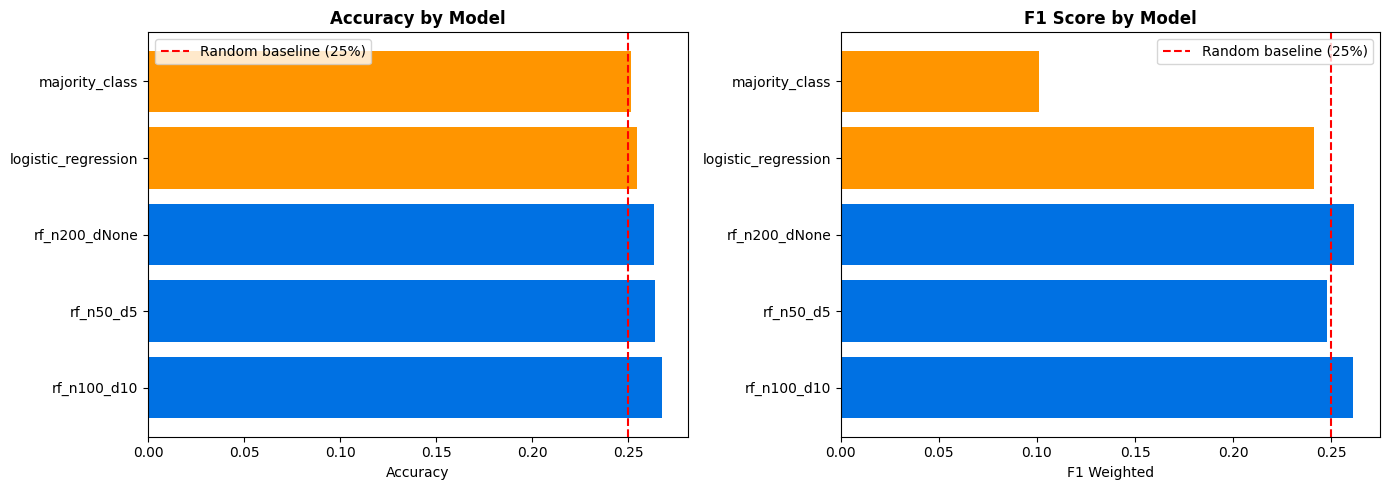

In [7]:
# Compare all runs
print("=== RESULTS COMPARISON ===\n")

results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('accuracy', ascending=False)
print(results_df.round(4))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#0071e3' if 'rf' in r else '#ff9500' for r in results_df.index]

axes[0].barh(results_df.index, results_df['accuracy'], color=colors)
axes[0].set_title('Accuracy by Model', fontweight='bold')
axes[0].set_xlabel('Accuracy')
axes[0].axvline(0.25, color='red', linestyle='--', label='Random baseline (25%)')
axes[0].legend()

axes[1].barh(results_df.index, results_df['f1'], color=colors)
axes[1].set_title('F1 Score by Model', fontweight='bold')
axes[1].set_xlabel('F1 Weighted')
axes[1].axvline(0.25, color='red', linestyle='--', label='Random baseline (25%)')
axes[1].legend()

plt.tight_layout()
plt.savefig('experiment_comparison.png', dpi=150, bbox_inches='tight')
plt.show()